<img src="images/Labs/III/i.jpeg" alt="scheme" height=70% width=80%>


По сравнению с Contrastive Loss, ArcFace имеет несколько преимуществ.

ArcFace не требует определения порога для различения положительных и отрицательных пар, что упрощает реализацию.

ArcFace явно изучает дискриминационные угловые отношения между классами, что приводит к улучшению межклассовлму разделению.

В Contrastive Loss наблюдается комбинаторный взрыв количества пар лиц, особенно для крупномасштабных наборов данных, что приводит к значительному увеличению количества шагов обучения.

Обучение ArcFace можно проводить без анализа выборки.

ArcFace показал превосходную производительность в крупномасштабных задачах идентификации лиц, где количество идентификаторов огромно.

<img src="images/Labs/III/angle_loss.png" alt="scheme" height=60% width=60%>

<img src="images/Labs/III/SoftmaxArcface.png" alt="scheme" height=50% width=50%>

### ArcFace Loss

<img src="images/Labs/III/Loss.png" alt="scheme" height=70% width=70%>

where **S** is the scaling factor,

**m** is the angular margin (m ~ 28.6),

**theta** is the angle between the feature and the weight vector of the ground truth class, and 

**theta_j** is the angle between the feature and the weight vector of all other classes.

<img src="images/Labs/III/arcface.jpg" alt="scheme" height=90% width=90%>

In [ ]:
# final_layer:

class CosineComponent(nn.Module):
    
    def __init__(self, emb_size, output_classes):
        super().__init__()
        self.W = nn.Parameter(torch.Tensor(emb_size, output_classes))
        nn.init.kaiming_uniform_(self.W)

    def forward(self, x):
        # Step 1:
        x_norm = F.normalize(x)
        W_norm = F.normalize(self.W, dim=0)
        # Step 2:
        return x_norm @ W_norm

In [ ]:
def arcface_loss(cosine, target, m=.4):
    # this prevents nan when a value slightly crosses 1.0 due to numerical error
    cosine = cosine.clip(-1+1e-7, 1-1e-7) 
    # Step 3:
    arcosine = cosine.arccos()
    # Step 4:
    arcosine += F.one_hot(target, num_classes = output_classes) * m
    # Step 5:
    cosine2 = arcosine.cos()
    # Step 6:
    return F.cross_entropy(cosine2, target)

### Reformulate the cross-entropy loss

<img src="images/Labs/III/CELoss.png" alt="scheme" height=50% width=50%>

<img src="images/Labs/III/CE_Arc.png" alt="scheme" height=50% width=50%>

https://arxiv.org/pdf/1801.07698

In [1]:
!pip install pytorch-metric-learning

https://kevinmusgrave.github.io/pytorch-metric-learning/losses/#arcfaceloss

Example

https://github.com/KevinMusgrave/pytorch-metric-learning/blob/master/examples/notebooks/SubCenterArcFaceMNIST.ipynb

### Задание

1) датасет:
/mnt/data/EuroSAT_MS
внутри папки AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop, residential, River, SeaLake

2) Используя ArcFace Loss обучить нейронку кодировать изображения одного класса похожим образом (всего 10 классов ~3000 изображений на класс)

3) С помощью t-SNE визуализировать результаты работы (использовать тестовый датасет)

4) Визуализировать результаты работы (inference) в виде - пара изображений + distance

#### Dataset

https://github.com/phelber/EuroSAT?tab=readme-ov-file

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
ArcFace Training для мультиспектрального EuroSAT (13 каналов Sentinel-2)
Автор: [Ваше имя]
Дата: 2026
"""

import os
import math
import random
import tifffile
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

DATA_DIR = "/mnt/data/EuroSAT_MS"
EMBEDDING_DIM = 128
NUM_CLASSES = 10
IN_CHANNELS = 13  # Sentinel-2: 13 спектральных каналов
IMG_SIZE = 64
BATCH_SIZE = 32  # Уменьшено для 13-канальных данных (память!)
EPOCHS = 25
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

# Фиксируем случайность для воспроизводимости
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"Device: {DEVICE}")
print(
    f"Channels: {IN_CHANNELS} | Embedding: {EMBEDDING_DIM} | Classes: {NUM_CLASSES}"
)


class EuroSAT_MSDataset(Dataset):
    """
    Датасет для мультиспектральных изображений EuroSAT (GeoTIFF, 13 каналов).
    Возвращает тензоры формы (13, 64, 64) с нормализацией [0, 1].
    """

    def __init__(self, root_dir, transform=None):
        self.root = root_dir
        self.transform = transform  # Экземпляр TensorAugmentations
        self.channels = IN_CHANNELS
        self.img_size = IMG_SIZE

        # Собираем классы
        self.classes = sorted(
            [
                d
                for d in os.listdir(root_dir)
                if os.path.isdir(os.path.join(root_dir, d))
            ]
        )
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        # Собираем список (путь, лейбл)
        self.samples = []
        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".tif", ".tiff")):
                    self.samples.append(
                        (os.path.join(cls_dir, fname), self.class_to_idx[cls_name])
                    )

        print(
            f"Загружено {len(self.samples)} изображений из {len(self.classes)} классов"
        )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        # 1. Загрузка TIFF через tifffile
        img = tifffile.imread(path)  # (H, W, C) или (C, H, W)

        # 2. Приводим к (C, H, W)
        if img.shape[-1] == self.channels:
            img = np.moveaxis(img, -1, 0)
        elif img.shape[0] != self.channels:
            raise ValueError(f"Неожиданная форма {img.shape} в {path}")

        # 3. Конвертируем в torch.Tensor
        img_tensor = torch.from_numpy(img).float()  # (13, 64, 64)

        # 4. Нормализация: Sentinel-2 обычно 0-65535 (16-bit)
        # Если данные уже в 0-1 или 0-255 — адаптируйте этот шаг!
        img_tensor = img_tensor / 65535.0
        img_tensor = torch.clamp(img_tensor, 0.0, 1.0)

        # 5. Аугментации (если переданы)
        if self.transform is not None:
            img_tensor = self.transform(img_tensor)

        return img_tensor, label


class TensorAugmentations:
    """
    Простые аугментации для многоканальных тензоров (C, H, W).
    Работает напрямую с torch.Tensor, без PIL.
    """

    def __init__(self, training=True, p_flip=0.5, p_rot=0.5, p_brightness=0.3):
        self.training = training
        self.p_flip = p_flip
        self.p_rot = p_rot
        self.p_brightness = p_brightness

    def __call__(self, x):
        if not self.training:
            return x

        # RandomHorizontalFlip
        if random.random() < self.p_flip:
            x = torch.flip(x, dims=[2])

        # RandomVerticalFlip
        if random.random() < self.p_flip:
            x = torch.flip(x, dims=[1])

        # RandomRotation: 0°, 90°, 180°, 270°
        if random.random() < self.p_rot:
            k = random.randint(0, 3)
            if k > 0:
                x = torch.rot90(x, k=k, dims=[1, 2])

        # RandomBrightness: мультипликативный шум
        if random.random() < self.p_brightness:
            factor = random.uniform(0.8, 1.2)
            x = torch.clamp(x * factor, 0.0, 1.0)

        # RandomGaussianNoise (лёгкий)
        if random.random() < 0.3:
            noise = torch.randn_like(x) * 0.01
            x = torch.clamp(x + noise, 0.0, 1.0)

        return x


class ArcFaceLoss(nn.Module):
    """
    ArcFace: Additive Angular Margin Loss.
    s=30.0, m=0.50 — стандартные гиперпараметры для хороших результатов.
    """

    def __init__(self, s=30.0, m=0.50):
        super().__init__()
        self.s = s
        self.m = m
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)  # порог для численной стабильности
        self.mm = math.sin(math.pi - m) * m

    def forward(self, cos_theta, labels):
        """
        cos_theta: [B, C] — косинусные сходства (уже нормализованные)
        labels: [B] — индексы классов
        """
        # sin²θ = 1 - cos²θ (с защитой от отрицательных значений из-за флоат-ошибок)
        sin_theta = torch.sqrt(torch.clamp(1.0 - cos_theta**2, min=0.0))

        # cos(θ + m) = cosθ·cos(m) - sinθ·sin(m)
        cos_theta_m = cos_theta * self.cos_m - sin_theta * self.sin_m

        # Численная стабильность: если θ > π - m, используем линейную аппроксимацию
        cos_theta_m = torch.where(
            cos_theta > self.th,
            cos_theta_m,
            cos_theta - self.mm,  # линейный спад за пределами
        )

        # One-hot encoding лейблов
        one_hot = torch.zeros_like(cos_theta)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1.0)

        # Применяем маржин только к правильному классу
        output = (one_hot * cos_theta_m) + ((1.0 - one_hot) * cos_theta)

        # Масштабируем и считаем CrossEntropy
        output = output * self.s
        return F.cross_entropy(output, labels)


class EmbeddingNet(nn.Module):
    """
    ResNet18 backbone, модифицированный под 13 входных каналов.
    Возвращает L2-нормализованные эмбеддинги размера EMBEDDING_DIM.
    """

    def __init__(self, emb_dim=EMBEDDING_DIM, in_channels=IN_CHANNELS):
        super().__init__()

        # Загружаем ResNet18 БЕЗ предобученных весов
        # (предобученные веса только для 3 каналов, не подходят для 13)
        resnet = models.resnet18(weights=None)

        # Заменяем первый conv-слой под нужное число каналов
        resnet.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False,
        )

        # Убираем оригинальный fully-connected слой
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])

        # Новый FC-слой для эмбеддингов
        self.fc = nn.Linear(resnet.fc.in_features, emb_dim)
        self.bn = nn.BatchNorm1d(emb_dim)

    def forward(self, x):
        x = self.backbone(x)  # → [B, 512, 1, 1]
        x = torch.flatten(x, 1)  # → [B, 512]
        x = self.fc(x)  # → [B, EMBEDDING_DIM]
        x = self.bn(x)  # BatchNorm для стабильности
        return F.normalize(x, p=2, dim=1)  # L2-нормализация


class ArcFaceClassifier(nn.Module):
    """
    Линейный классификатор для ArcFace.
    Возвращает косинусные сходства между эмбеддингами и весами классов.
    """

    def __init__(self, emb_dim=EMBEDDING_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        # Веса инициализируются случайно, будут обучаться
        self.weight = nn.Parameter(torch.randn(emb_dim, num_classes))

    def forward(self, x):
        """
        x: [B, emb_dim] — L2-нормализованные эмбеддинги
        return: [B, num_classes] — косинусные сходства
        """
        # Нормализуем веса по колонкам (каждый класс — единичный вектор)
        w_norm = F.normalize(self.weight, p=2, dim=0)
        # Косинусное сходство = dot(embedding, weight_class)
        return x @ w_norm


def visualize_tsne(embeddings, labels, class_names):
    
    # t-SNE уменьшает размерность до 2D
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        max_iter=1000,
        init="pca",
        random_state=SEED,
        verbose=0,
    )
    emb_2d = tsne.fit_transform(embeddings)

    # Рисуем
    plt.figure(figsize=(12, 9))
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))

    for i, cls_name in enumerate(class_names):
        mask = labels == i
        plt.scatter(
            emb_2d[mask, 0],
            emb_2d[mask, 1],
            c=[colors[i]],
            label=cls_name,
            s=30,
            alpha=0.7,
            edgecolors="white",
            linewidth=0.5,
        )

    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    plt.title("t-SNE: EuroSAT-MS Embeddings (ArcFace, 13 channels)", fontsize=14)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()


full_dataset = EuroSAT_MSDataset(
        DATA_DIR, transform=TensorAugmentations(training=True)
    )
class_names = full_dataset.classes

train_size = int(len(full_dataset) * 0.8)
test_size = len(full_dataset) - train_size
train_ds, test_ds = random_split(
        full_dataset,
        [train_size, test_size],
        generator=torch.Generator().manual_seed(SEED),
    )

test_ds.dataset.transform = TensorAugmentations(training=False)

train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
        persistent_workers=False,
    )
test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
    )

embedding_net = EmbeddingNet(emb_dim=EMBEDDING_DIM, in_channels=IN_CHANNELS).to(
        DEVICE
    )
classifier = ArcFaceClassifier(emb_dim=EMBEDDING_DIM, num_classes=NUM_CLASSES).to(
        DEVICE
    )

criterion = ArcFaceLoss(s=30.0, m=0.50)
optimizer = optim.AdamW(
        list(embedding_net.parameters()) + list(classifier.parameters()),
        lr=LEARNING_RATE,
        weight_decay=1e-4,
    )
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


for epoch in range(EPOCHS):
    embedding_net.train()
    classifier.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (imgs, labels) in enumerate(train_loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

            # Forward pass
        embeddings = embedding_net(imgs)  # [B, 128]
        cos_theta = classifier(embeddings)  # [B, 10]
        loss = criterion(cos_theta, labels)

            # Backward pass
        loss.backward()
        optimizer.step()

            # Статистика
        running_loss += loss.item()
        preds = cos_theta.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    scheduler.step()
    avg_loss = running_loss / len(train_loader)
    acc = 100.0 * correct / total

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | Acc: {acc:.2f}%")

embedding_net.eval()
classifier.eval()

all_embeddings = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        embs = embedding_net(imgs)  # [B, 128]
        all_embeddings.append(embs.cpu().numpy())
        all_labels.append(labels.numpy())

embeddings_np = np.vstack(all_embeddings)  # [N_test, 128]
labels_np = np.concatenate(all_labels)  # [N_test]


Device: cuda
Channels: 13 | Embedding: 128 | Classes: 10
Загружено 27000 изображений из 10 классов
Epoch  1/25 | Loss: 8.9040 | Acc: 67.44%
Epoch  5/25 | Loss: 3.3936 | Acc: 87.53%
Epoch 10/25 | Loss: 2.0651 | Acc: 90.77%
Epoch 15/25 | Loss: 1.3544 | Acc: 93.64%
Epoch 20/25 | Loss: 0.7805 | Acc: 96.66%
Epoch 25/25 | Loss: 0.5597 | Acc: 97.72%


In [10]:
def visualize_pairs(dataset, embeddings, labels, class_names, n_pairs=5):
    """
    Визуализация пар изображений с указанием косинусного расстояния.
    50% пар — одного класса, 50% — разных.
    """

    fig, axes = plt.subplots(n_pairs, 2, figsize=(12, 5 * n_pairs))
    if n_pairs == 1:
        axes = axes.reshape(1, -1)

    np.random.seed(SEED)

    # Denorm для отображения: из [0,1] в [0,255] uint8
    def tensor_to_display(img_tensor):
        # Sentinel-2: B4=Red(3), B3=Green(2), B2=Blue(1)
        # matplotlib.imshow ожидает порядок каналов R, G, B
        rgb = img_tensor[[3, 2, 1], :, :].cpu().numpy()  # (3, H, W)
        rgb = np.moveaxis(rgb, 0, -1)  # → (H, W, 3)
        
        # 🌟 Автоматическое растяжение контраста по перцентилям
        # Спутниковые снимки имеют узкий рабочий диапазон. 
        # Обрезаем экстремумы (2% и 98%) и масштабируем в [0, 1]
        p_low, p_high = np.percentile(rgb, (2, 98))
        rgb_stretched = np.clip((rgb - p_low) / (p_high - p_low + 1e-6), 0.0, 1.0)
        
        return (rgb_stretched * 255).astype(np.uint8)

    for k in range(n_pairs):
        # Выбираем пару: с вероятностью 50% — same class, иначе — different
        if np.random.rand() > 0.5:
            # Same class
            cls = np.random.choice(np.unique(labels))
            idxs = np.where(labels == cls)[0]
            if len(idxs) < 2:
                # Если в классе мало примеров, берём любые два
                i, j = np.random.choice(len(labels), 2, replace=False)
            else:
                i, j = np.random.choice(idxs, 2, replace=False)
        else:
            # Different classes
            cls1, cls2 = np.random.choice(np.unique(labels), 2, replace=False)
            i = np.random.choice(np.where(labels == cls1)[0])
            j = np.random.choice(np.where(labels == cls2)[0])

        # Получаем данные
        img1, lbl1 = dataset[i]
        img2, lbl2 = dataset[j]
        emb1, emb2 = embeddings[i], embeddings[j]

        # Косинусное расстояние: 1 - cosine_similarity
        cos_sim = np.dot(emb1, emb2)  # оба вектора уже L2-нормализованы
        cos_dist = 1.0 - cos_sim

        # Отображаем
        axes[k, 0].imshow(tensor_to_display(img1))
        axes[k, 0].set_title(f"{class_names[lbl1]}", fontsize=11, fontweight="bold")
        axes[k, 0].axis("off")

        axes[k, 1].imshow(tensor_to_display(img2))
        title = f"{class_names[lbl2]}\nCosine Dist: {cos_dist:.3f}"
        color = "green" if cos_dist < 0.3 else ("orange" if cos_dist < 0.6 else "red")
        axes[k, 1].set_title(title, fontsize=11, fontweight="bold", color=color)
        axes[k, 1].axis("off")

    plt.tight_layout()
    plt.show()

In [12]:
# Быстрая количественная оценка (можно добавить в скрипт):
from sklearn.metrics import silhouette_score

score = silhouette_score(embeddings_np, labels_np)
print(f"Silhouette Score: {score:.3f}")
# > 0.3 — хорошо, > 0.5 — отлично, < 0.1 — модель не научилась разделять

Silhouette Score: 0.713


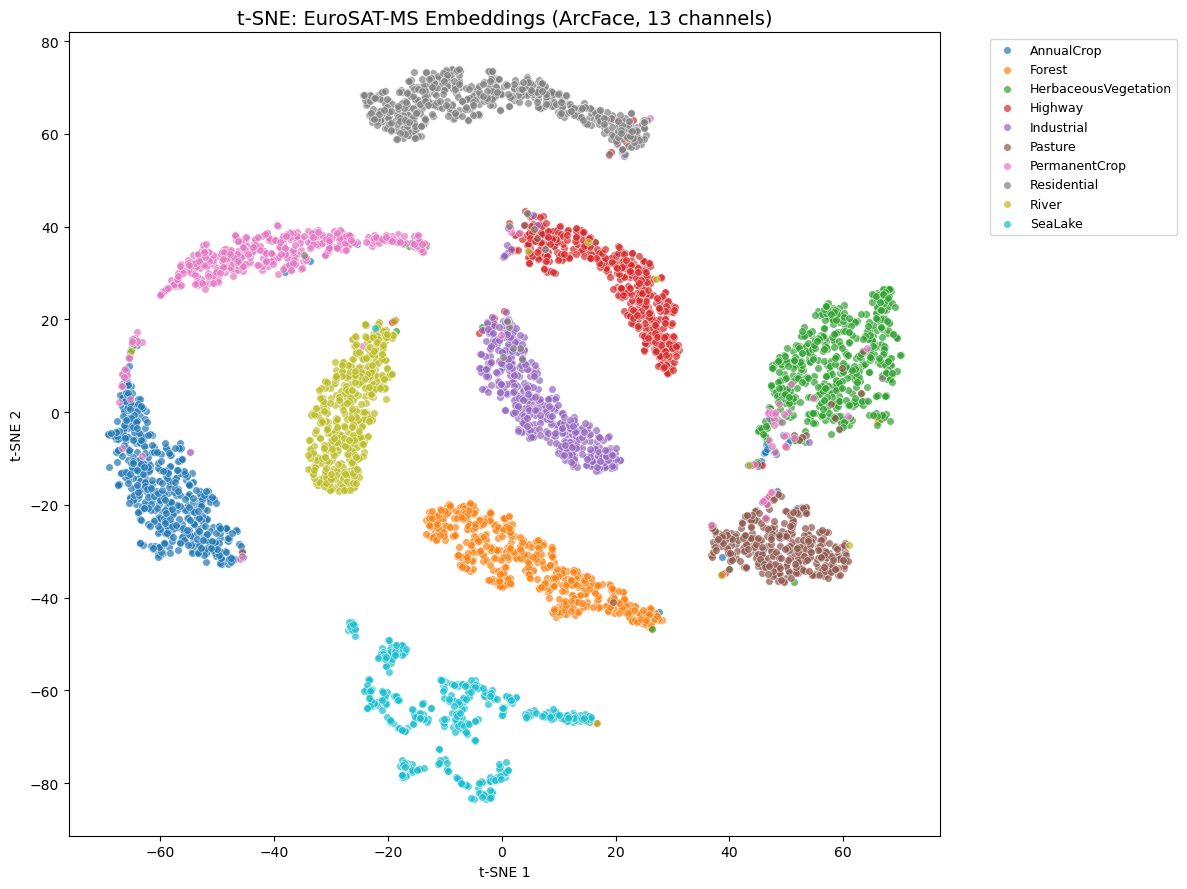

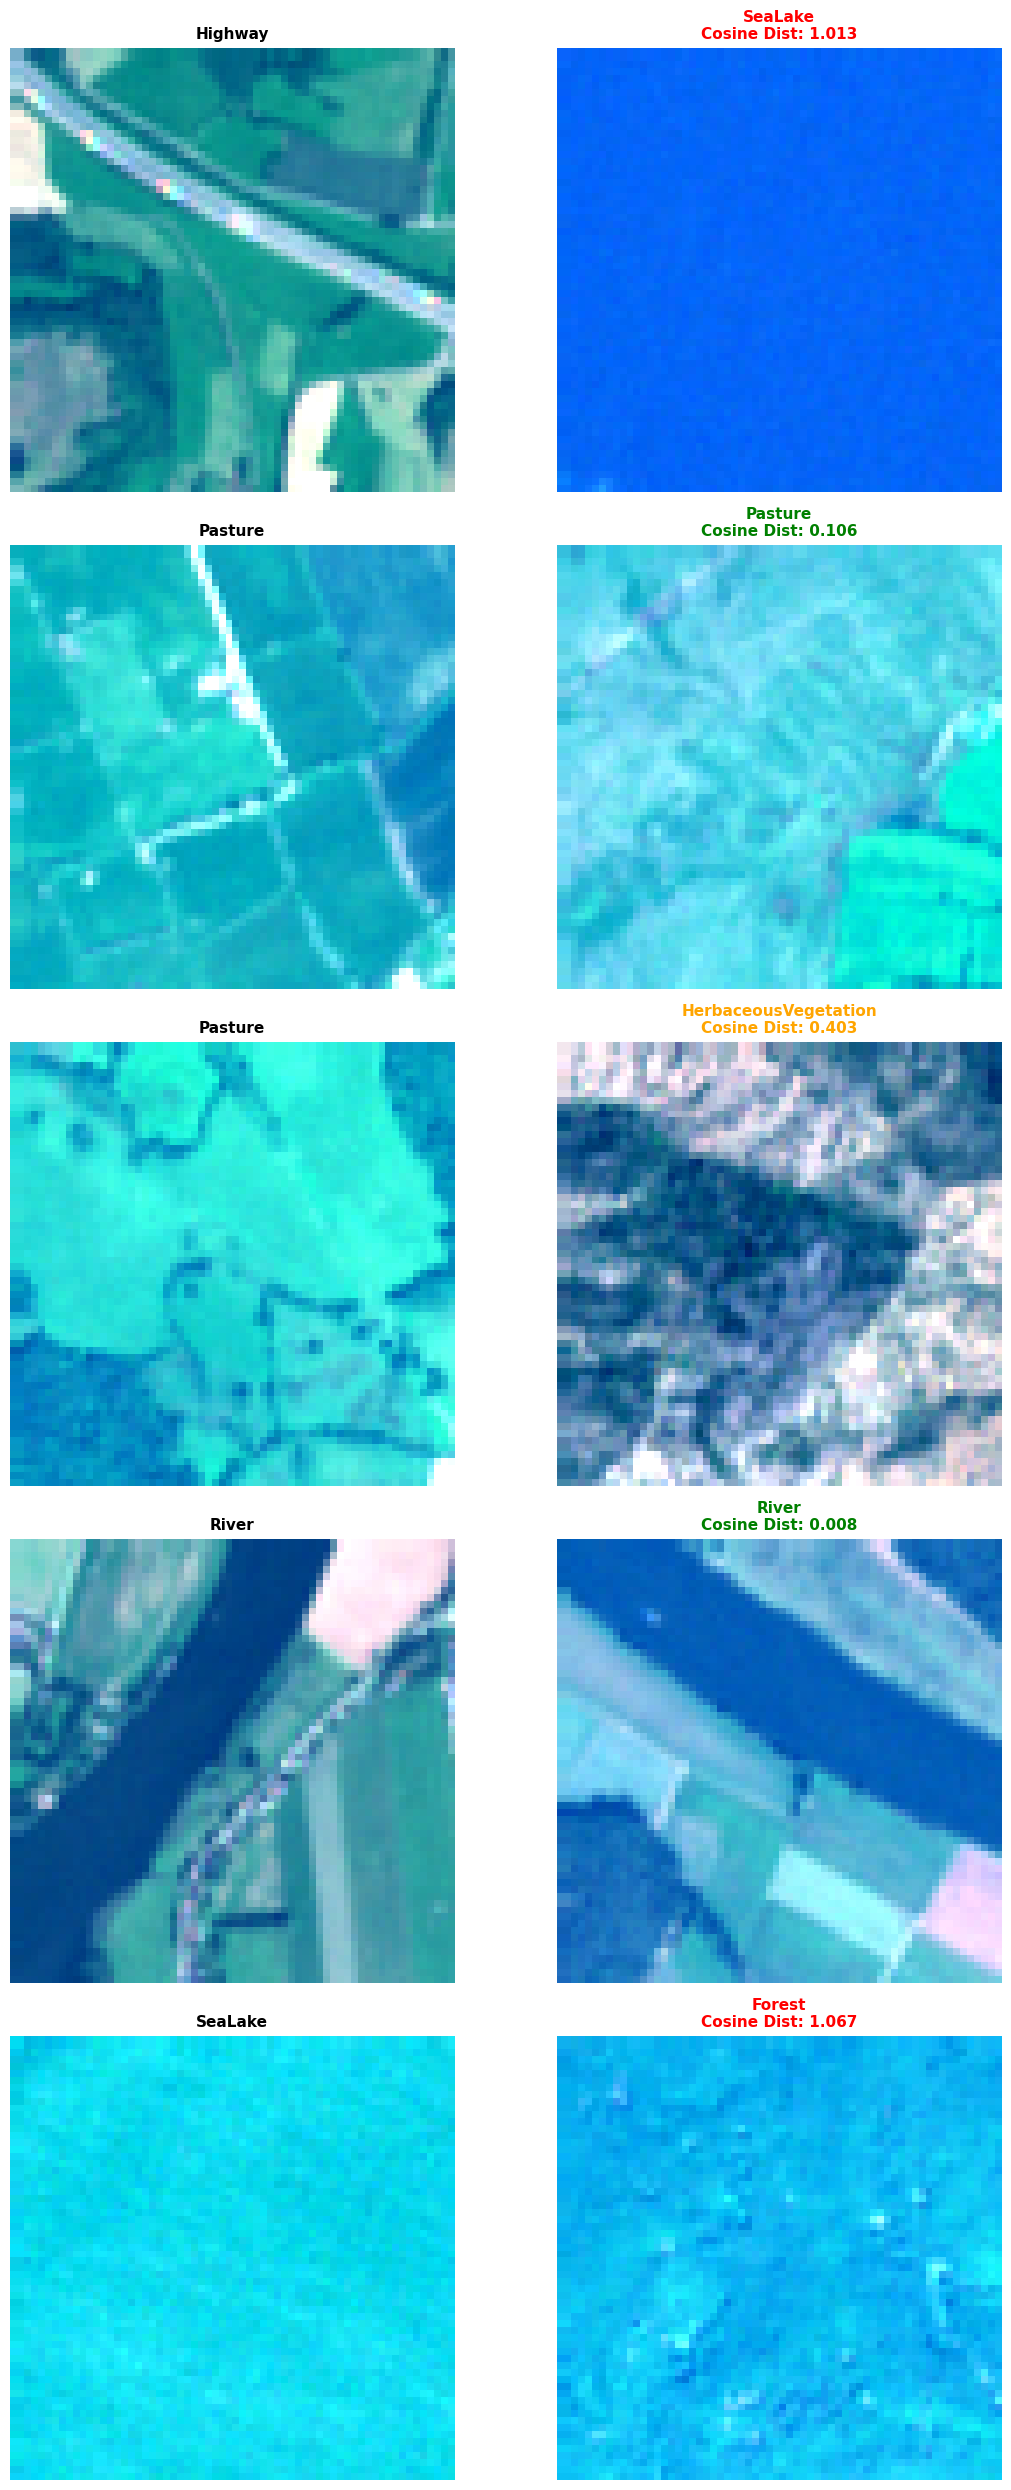

In [11]:
visualize_tsne(embeddings_np, labels_np, class_names)

visualize_pairs(test_ds, embeddings_np, labels_np, class_names, n_pairs=5)

In [ ]:
Cosine Distance = 1 - Cosine Similarity
Диапазон: [0.0, 2.0], но для нормализованных векторов обычно [0.0, 1.0]

🟢 0.0 – 0.3:  "Очень похожи" — модель считает изображения почти идентичными
🟡 0.3 – 0.6:  "Умеренно похожи" — есть общие черты, но и различия
🔴 0.6 – 1.0:  "Похожи мало" — модель видит существенные различия